**Overview**  
This notebook describes Cc prediction with torch-molecule models. There are 9 DL models for properties predction (mostly, different types of GNNs). The structure of notebook resembles the one, employing shallow methods. First, we assess model performance and select the best one 

In [1]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt

from torch_molecule import GREAMolecularPredictor
from tqdm import tqdm

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import GridSearchCV, train_test_split, cross_val_score, cross_val_predict
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.svm import SVR
from hyperopt import tpe, Trials, hp, fmin, STATUS_OK
from functools import partial
from sklearn.neighbors import KNeighborsRegressor

In [2]:
from torch_molecule import GREAMolecularPredictor, BFGNNMolecularPredictor, SGIRMolecularPredictor, GRINMolecularPredictor, DIRMolecularPredictor, SSRMolecularPredictor, IRMMolecularPredictor, RPGNNMolecularPredictor, GNNMolecularPredictor, LSTMMolecularPredictor


We import dataset, containing Cc values vs SMILES of molecules

In [132]:
data_non_ionic = pd.read_csv('Data_non_ionic.csv', usecols=[1,2])

In [134]:
def calculate_to_score(estimator, dataset):
    train, test = train_test_split(dataset, random_state=0, train_size=0.75)
    train, val = train_test_split(train, random_state=0, train_size=0.12)
    
    est = estimator
    best_estimator  = est.autofit(X_train = list(train['SMILES']),
                                        y_train = list(train['Cc ']),
                                        X_val = list(val['SMILES']),
                                        y_val = list(val['Cc ']), n_trials = 10)    
    
    predictions= best_estimator.predict(list(test['SMILES']))['prediction']
    predictions_train = best_estimator.predict(list(train['SMILES']))['prediction']
    scores['Estimator'].append(est.model_name)
    scores['R2_test'].append(r2_score(test['Cc '], predictions))
    scores['R2_train'].append(r2_score(train['Cc '], predictions_train))
        
    scores['RMSE_test'].append(root_mean_squared_error(test['Cc '], predictions))
    scores['RMSE_train'].append(root_mean_squared_error(train['Cc '], predictions_train))

        
    scores['MAE_test'].append(mean_absolute_error(test['Cc '], predictions))
    scores['MAE_train'].append(mean_absolute_error(train['Cc '], predictions_train))

In [135]:
scores = { 'Estimator': [],  'R2_test':[], 'RMSE_test':[], 'MAE_test':[], 'R2_train':[], 'RMSE_train':[], 'MAE_train':[] }
trained_models = {}

Let's initialize scores dictionary and test function with Logistic Regression

In [20]:
models = [GREAMolecularPredictor, BFGNNMolecularPredictor, GRINMolecularPredictor, DIRMolecularPredictor, SSRMolecularPredictor, IRMMolecularPredictor, RPGNNMolecularPredictor,GNNMolecularPredictor]

In [21]:
for model in tqdm(models):
    calculate_to_score(model(device = 'cuda:0'), dataset = data_non_ionic)

100%|██████████| 8/8 [1:43:33<00:00, 776.69s/it]   


In [22]:
pd.DataFrame(scores)

,Estimator,R2_test,RMSE_test,MAE_test,R2_train,RMSE_train,MAE_train
0,GREAMolecularPredictor,-0.105418,1.962004,1.321146,0.972535,0.432490,0.343741
1,BFGNNMolecularPredictor,-1.183498,2.757484,1.465650,0.969040,0.459186,0.316376
2,GRINMolecularPredictor,-0.723454,2.449832,1.684017,0.770503,1.250191,0.998332
3,DIRMolecularPredictor,-0.277481,2.109181,1.536233,0.440535,1.951977,1.515149
4,SSRMolecularPredictor,-0.661685,2.405530,1.311938,0.782461,1.217185,0.838305
5,IRMMolecularPredictor,-1.035030,2.662085,1.823799,0.677472,1.482082,1.176703
6,RPGNNMolecularPredictor,-0.280865,2.111973,1.463936,0.919851,0.738816,0.484820
7,GNNMolecularPredictor,-0.122486,1.977093,1.389477,0.903009,0.812743,0.572637


Two models:
1. SGIRMolecular predictor
2. LSTMMolecular predictor

Must be done and loaded to scores manually. First we start with SGIRMolecular predictor, which requires the use of unlabelled SMILES

In [27]:
sgir = SGIRMolecularPredictor()
train, test = train_test_split(data_non_ionic, random_state=0, train_size=0.75)
val, unlb = train_test_split(data_non_ionic, random_state=0, train_size=0.5)

In [28]:
sgir.autofit(X_train = list(train['SMILES']),y_train = list(train['Cc ']),
             X_val = list(val['SMILES']),y_val  =list(val['Cc ']), X_unlbl = list(unlb['SMILES']))

SGIRMolecularPredictor(device=device(type='cuda', index=0), model_name='SGIRMolecularPredictor', model_class=<class 'torch_molecule.predictor.grea.model.GREA'>, model=GREA(
  (graph_encoder): GNN_node(
    (atom_encoder): AtomEncoder(
      (atom_embedding_list): ModuleList(
        (0): Embedding(120, 94, max_norm=1)
        (1): Embedding(5, 94, max_norm=1)
        (2-3): 2 x Embedding(12, 94, max_norm=1)
        (4): Embedding(10, 94, max_norm=1)
        (5-6): 2 x Embedding(6, 94, max_norm=1)
        (7-8): 2 x Embedding(2, 94, max_norm=1)
      )
    )
    (bond_encoder): BondEncoder(
      (bond_embedding_list): ModuleList(
        (0): Embedding(5, 94, max_norm=1)
        (1): Embedding(6, 94, max_norm=1)
        (2): Embedding(2, 94, max_norm=1)
      )
    )
    (convs): ModuleList(
      (0-7): 8 x GINConv()
    )
    (batch_norms): ModuleList(
      (0-7): 8 x GraphSizeNorm()
    )
  )
  (separator): Separator(
    (rationale_encoder): GNN_node(
      (atom_encoder): AtomEnc

In [39]:
predictions= sgir.predict(list(test['SMILES']))['prediction']
predictions_train = sgir.predict(list(train['SMILES']))['prediction']

scores['Estimator'].append(sgir.model_name)
scores['R2_test'].append(r2_score(test['Cc '], predictions))
scores['R2_train'].append(r2_score(train['Cc '], predictions_train))
        
scores['RMSE_test'].append(root_mean_squared_error(test['Cc '], predictions))
scores['RMSE_train'].append(root_mean_squared_error(train['Cc '], predictions_train))

        
scores['MAE_test'].append(mean_absolute_error(test['Cc '], predictions))
scores['MAE_train'].append(mean_absolute_error(train['Cc '], predictions_train))

Then we perform the same operations with LSTM predictor, which requires the use of target inout as Numpy array, not list

In [45]:
train, test = train_test_split(data_non_ionic, random_state=0, train_size=0.75)
val, test = train_test_split(test, random_state=0, train_size=0.5)

In [46]:
lstm = LSTMMolecularPredictor()

In [47]:
lstm.autofit(X_train = list(train['SMILES']),
             y_train = np.array(train['Cc ']),
             X_val = list(val['SMILES']),
             y_val = np.array(val['Cc ']))

C:\Users\Timur\anaconda3\envs\ChemInfo-Pytorch\Lib\site-packages\torch\nn\modules\loss.py:608: UserWarning: Using a target size (torch.Size([57])) that is different to the input size (torch.Size([57, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
C:\Users\Timur\anaconda3\envs\ChemInfo-Pytorch\Lib\site-packages\torch\nn\modules\loss.py:608: UserWarning: Using a target size (torch.Size([57])) that is different to the input size (torch.Size([57, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
C:\Users\Timur\anaconda3\envs\ChemInfo-Pytorch\Lib\site-packages\torch\nn\modules\loss.py:608: UserWarning: Using a target size (torch.Size([57])) that is different to the input size (torch.Size([57, 1])). This will likely lead to incorrect results due to broa

LSTMMolecularPredictor(device=device(type='cuda', index=0), model_name='LSTMMolecularPredictor', model_class=<class 'torch_molecule.predictor.lstm.model.LSTM'>, model=LSTM(
  (embedding): Embedding(54, 21)
  (lstm1): LSTM(21, 86, batch_first=True, bidirectional=True)
  (lstm2): LSTM(172, 86, batch_first=True, bidirectional=True)
  (timedist_dense): Linear(in_features=172, out_features=43, bias=True)
  (relu): ReLU()
  (fc): Linear(in_features=8600, out_features=1, bias=True)
), is_fitted_=True, num_task=1, task_type='regression', input_dim=54, output_dim=21, LSTMunits=86, max_input_len=200, batch_size=128, epochs=500, loss_criterion=MSELoss(), evaluate_criterion=<function mean_absolute_error at 0x00000255D6942480>, evaluate_higher_better=False, learning_rate=0.009094020113564808, weight_decay=7.008065391680066e-08, patience=50, use_lr_scheduler=False, scheduler_factor=0.23345074302472835, scheduler_patience=5, verbose=False, fitting_loss=[6.076171875, 89.9295654296875, 6.30956411361694

In [48]:
predictions= lstm.predict(list(test['SMILES']))['prediction']
predictions_train = lstm.predict(list(train['SMILES']))['prediction']

scores['Estimator'].append(lstm.model_name)
scores['R2_test'].append(r2_score(test['Cc '], predictions))
scores['R2_train'].append(r2_score(train['Cc '], predictions_train))
        
scores['RMSE_test'].append(root_mean_squared_error(test['Cc '], predictions))
scores['RMSE_train'].append(root_mean_squared_error(train['Cc '], predictions_train))

        
scores['MAE_test'].append(mean_absolute_error(test['Cc '], predictions))
scores['MAE_train'].append(mean_absolute_error(train['Cc '], predictions_train))

In [49]:
pd.DataFrame(scores)

,Estimator,R2_test,RMSE_test,MAE_test,R2_train,RMSE_train,MAE_train
0,GREAMolecularPredictor,-0.105418,1.962004,1.321146,0.972535,0.432490,0.343741
1,BFGNNMolecularPredictor,-1.183498,2.757484,1.465650,0.969040,0.459186,0.316376
2,GRINMolecularPredictor,-0.723454,2.449832,1.684017,0.770503,1.250191,0.998332
3,DIRMolecularPredictor,-0.277481,2.109181,1.536233,0.440535,1.951977,1.515149
4,SSRMolecularPredictor,-0.661685,2.405530,1.311938,0.782461,1.217185,0.838305
5,IRMMolecularPredictor,-1.035030,2.662085,1.823799,0.677472,1.482082,1.176703
6,RPGNNMolecularPredictor,-0.280865,2.111973,1.463936,0.919851,0.738816,0.484820
7,GNNMolecularPredictor,-0.122486,1.977093,1.389477,0.903009,0.812743,0.572637
8,SGIRMolecularPredictor,0.796594,2.524374,1.229710,0.964259,0.465941,0.264838
9,LSTMMolecularPredictor,-0.044157,7.615885,3.739675,0.003607,2.460164,1.834284


In [50]:
with open('scores_non_ionic_torch.pickle', 'wb') as output:
    pickle.dump(scores, output)

As we can see, SGIR model have the best generalization performace (highest R2, lowest RMSE - about 0.36 lower, than for the best shallow model). We will perform hyperparameter tuning for SGIR using *hyperopt* package

In [52]:
def objective(params, X):
    SGIR = SGIRMolecularPredictor(num_layer = params['num_layer'], hidden_size = params['hidden_size'], gnn_type = params['gnn_type'], graph_pooling = params['graph_pooling'], weight_decay = params['weight_decay'], use_lr_scheduler = params['use_lr_scheduler'])
    kf = KFold(n_splits = 5)
    cv_rmse_results = []
    cv_mae_results = []
    cv_r2_results = []
    
    for train_unlb_indices, test_indices in kf.split(X):
        
        train_indices, unlbl_indices = train_test_split(train_unlb_indices, random_state = 0, train_size=0.8)
        
        X_train = X.iloc[train_indices, :]['SMILES']
        y_train = X.iloc[train_indices, :]['Cc ']
        X_unlbl  = X.iloc[unlbl_indices, :]['SMILES']

        

        X_test = X.iloc[test_indices, :]['SMILES']
        y_test = X.iloc[test_indices, :]['Cc ']
        
        sgir.fit(X_train = list(X_train), y_train = list(y_train), X_unlbl = list(X_unlbl))

        predictions = sgir.predict(list(X_test))['prediction']
        
        cv_rmse_results.append(root_mean_squared_error(y_test, predictions))
        cv_mae_results.append(mean_absolute_error(y_test, predictions))
        cv_r2_results.append(r2_score(y_test, predictions))

    return {'loss':np.mean(cv_rmse_results), 'status':STATUS_OK, 'model':sgir, 'r2':-np.mean(cv_r2_results), 'mae':-np.mean(cv_mae_results)}

In [53]:
trials = Trials()

In [54]:
param_grid = {'num_layer': hp.randint('num_layer', 3,7),
              'hidden_size':hp.randint('hidden_size', 200, 400),
              'gnn_type': hp.choice('gnn_type', ["gin-virtual", "gcn-virtual", "gin", "gcn"]),
              'graph_pooling':hp.choice('graph_pooling', ['mean', 'sum', 'max']),
              'weight_decay':hp.loguniform('weight_decay', -13, -4),
              'use_lr_scheduler':hp.choice('use_lr_scheduler', [True, False])}
                                    

In [56]:
best = fmin(partial(objective, X = data_non_ionic), space = param_grid, trials = trials, algo = tpe.suggest, max_evals=  25)

  0%|          | 0/25 [00:00<?, ?trial/s, best loss=?]

C:\Users\Timur\anaconda3\envs\ChemInfo-Pytorch\Lib\site-packages\torch_molecule\predictor\sgir\modeling_sgir.py:121: UserWarning: No validation set provided. Using training set for validation.
  warnings.warn(

C:\Users\Timur\anaconda3\envs\ChemInfo-Pytorch\Lib\site-packages\torch_molecule\predictor\sgir\modeling_sgir.py:121: UserWarning: No validation set provided. Using training set for validation.
  warnings.warn(

C:\Users\Timur\anaconda3\envs\ChemInfo-Pytorch\Lib\site-packages\torch_molecule\predictor\sgir\modeling_sgir.py:121: UserWarning: No validation set provided. Using training set for validation.
  warnings.warn(

C:\Users\Timur\anaconda3\envs\ChemInfo-Pytorch\Lib\site-packages\torch_molecule\predictor\sgir\modeling_sgir.py:121: UserWarning: No validation set provided. Using training set for validation.
  warnings.warn(

C:\Users\Timur\anaconda3\envs\ChemInfo-Pytorch\Lib\site-packages\torch_molecule\predictor\sgir\modeling_sgir.py:121: UserWarning: No validation set provided

  4%|▍         | 1/25 [04:01<1:36:28, 241.21s/trial, best loss: 2.3490402093832286]

C:\Users\Timur\anaconda3\envs\ChemInfo-Pytorch\Lib\site-packages\torch_molecule\predictor\sgir\modeling_sgir.py:121: UserWarning: No validation set provided. Using training set for validation.
  warnings.warn(

C:\Users\Timur\anaconda3\envs\ChemInfo-Pytorch\Lib\site-packages\torch_molecule\predictor\sgir\modeling_sgir.py:121: UserWarning: No validation set provided. Using training set for validation.
  warnings.warn(

C:\Users\Timur\anaconda3\envs\ChemInfo-Pytorch\Lib\site-packages\torch_molecule\predictor\sgir\modeling_sgir.py:121: UserWarning: No validation set provided. Using training set for validation.
  warnings.warn(

C:\Users\Timur\anaconda3\envs\ChemInfo-Pytorch\Lib\site-packages\torch_molecule\predictor\sgir\modeling_sgir.py:121: UserWarning: No validation set provided. Using training set for validation.
  warnings.warn(

C:\Users\Timur\anaconda3\envs\ChemInfo-Pytorch\Lib\site-packages\torch_molecule\predictor\sgir\modeling_sgir.py:121: UserWarning: No validation set provided

  8%|▊         | 2/25 [07:30<1:25:19, 222.59s/trial, best loss: 2.2355203922618263]

...

 92%|█████████▏| 23/25 [1:27:52<07:25, 222.54s/trial, best loss: 2.208280475308075]

C:\Users\Timur\anaconda3\envs\ChemInfo-Pytorch\Lib\site-packages\torch_molecule\predictor\sgir\modeling_sgir.py:121: UserWarning: No validation set provided. Using training set for validation.
  warnings.warn(

C:\Users\Timur\anaconda3\envs\ChemInfo-Pytorch\Lib\site-packages\torch_molecule\predictor\sgir\modeling_sgir.py:121: UserWarning: No validation set provided. Using training set for validation.
  warnings.warn(

C:\Users\Timur\anaconda3\envs\ChemInfo-Pytorch\Lib\site-packages\torch_molecule\predictor\sgir\modeling_sgir.py:121: UserWarning: No validation set provided. Using training set for validation.
  warnings.warn(

C:\Users\Timur\anaconda3\envs\ChemInfo-Pytorch\Lib\site-packages\torch_molecule\predictor\sgir\modeling_sgir.py:121: UserWarning: No validation set provided. Using training set for validation.
  warnings.warn(

C:\Users\Timur\anaconda3\envs\ChemInfo-Pytorch\Lib\site-packages\torch_molecule\predictor\sgir\modeling_sgir.py:121: UserWarning: No validation set provided

 96%|█████████▌| 24/25 [1:32:17<03:55, 235.08s/trial, best loss: 2.208280475308075]

C:\Users\Timur\anaconda3\envs\ChemInfo-Pytorch\Lib\site-packages\torch_molecule\predictor\sgir\modeling_sgir.py:121: UserWarning: No validation set provided. Using training set for validation.
  warnings.warn(

C:\Users\Timur\anaconda3\envs\ChemInfo-Pytorch\Lib\site-packages\torch_molecule\predictor\sgir\modeling_sgir.py:121: UserWarning: No validation set provided. Using training set for validation.
  warnings.warn(

C:\Users\Timur\anaconda3\envs\ChemInfo-Pytorch\Lib\site-packages\torch_molecule\predictor\sgir\modeling_sgir.py:121: UserWarning: No validation set provided. Using training set for validation.
  warnings.warn(

C:\Users\Timur\anaconda3\envs\ChemInfo-Pytorch\Lib\site-packages\torch_molecule\predictor\sgir\modeling_sgir.py:121: UserWarning: No validation set provided. Using training set for validation.
  warnings.warn(

C:\Users\Timur\anaconda3\envs\ChemInfo-Pytorch\Lib\site-packages\torch_molecule\predictor\sgir\modeling_sgir.py:121: UserWarning: No validation set provided

100%|██████████| 25/25 [1:36:10<00:00, 230.82s/trial, best loss: 2.208280475308075]


In [57]:
print(best)

{'gnn_type': 2, 'graph_pooling': 1, 'hidden_size': 345, 'num_layer': 6, 'use_lr_scheduler': 0, 'weight_decay': 3.256490380772579e-05}


Let's finally fit the best estimator and plot predicted values vs true ones

In [137]:
train, test = train_test_split(data_non_ionic, random_state=0)
train, unlbl = train_test_split(train, random_state=0, train_size=0.9)

In [62]:
sgir = SGIRMolecularPredictor(gnn_type='gin', graph_pooling='sum', hidden_size=345, num_layer=6, use_lr_scheduler=True, weight_decay=3.256490380772579e-05)
sgir.fit(X_train = list(train['SMILES']),
               y_train=list(train['Cc ']),
               X_unlbl = list(unlbl['SMILES']))

C:\Users\Timur\anaconda3\envs\ChemInfo-Pytorch\Lib\site-packages\torch_molecule\predictor\sgir\modeling_sgir.py:121: UserWarning: No validation set provided. Using training set for validation.
  warnings.warn(


SGIRMolecularPredictor(device=device(type='cuda', index=0), model_name='SGIRMolecularPredictor', model_class=<class 'torch_molecule.predictor.grea.model.GREA'>, model=GREA(
  (graph_encoder): GNN_node(
    (atom_encoder): AtomEncoder(
      (atom_embedding_list): ModuleList(
        (0): Embedding(120, 345, max_norm=1)
        (1): Embedding(5, 345, max_norm=1)
        (2-3): 2 x Embedding(12, 345, max_norm=1)
        (4): Embedding(10, 345, max_norm=1)
        (5-6): 2 x Embedding(6, 345, max_norm=1)
        (7-8): 2 x Embedding(2, 345, max_norm=1)
      )
    )
    (bond_encoder): BondEncoder(
      (bond_embedding_list): ModuleList(
        (0): Embedding(5, 345, max_norm=1)
        (1): Embedding(6, 345, max_norm=1)
        (2): Embedding(2, 345, max_norm=1)
      )
    )
    (convs): ModuleList(
      (0-5): 6 x GINConv()
    )
    (batch_norms): ModuleList(
      (0-5): 6 x BatchNorm1d(345, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (separator): S

RMSE of predictor for test set is 1.4669486633042546
R2 value of predictor for test set is 0.5401200596833701
MAE value for test set is 1.1003697405865316


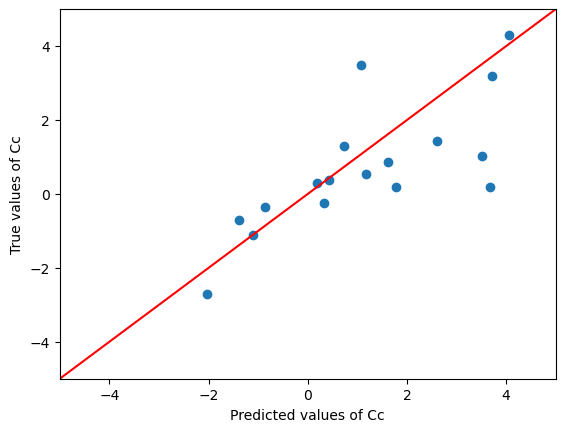

In [70]:
predictions = sgir.predict(list(test['SMILES']))

plt.plot(predictions['prediction'], test['Cc '], 'o')
plt.plot([-5, 5], [-5,5], 'r')
plt.xlabel('Predicted values of Cc')
plt.ylabel('True values of Cc')
plt.xlim(-5, 5)
plt.ylim(-5, 5)

print('RMSE of predictor for test set is {}'.format(root_mean_squared_error(predictions['prediction'], test['Cc '])))
print('R2 value of predictor for test set is {}'.format(r2_score(predictions['prediction'], test['Cc '])))
print('MAE value for test set is {}'.format(mean_absolute_error(predictions['prediction'], test['Cc '])))

In [138]:
def manual_cross_val_predict(cv, X, y, estimator, unlbl, random_state = 0, shuffle = True):
    X = X.reset_index(drop = True)
    y = y.reset_index(drop = True)
    y_pred = np.empty_like(y)
    kfold = KFold(n_splits=cv, shuffle = True, random_state = random_state)
    for train_idx, test_idx in kfold.split(X, y):
        model = estimator
        X_train = X[train_idx]
        y_train = y[train_idx]
        X_test = X[test_idx]
        y_test = y[test_idx]
        
        model.fit(X_train = list(X_train), y_train = list(y_train), X_unlbl = list(unlbl['SMILES']))
        y_pred[test_idx] = model.predict(list(X_test))['prediction'].squeeze()
    return y_pred

In [141]:
cross_val_predictions = manual_cross_val_predict(cv = 5, X = train['SMILES'], y = train['Cc '], 
                                                 estimator = SGIRMolecularPredictor(gnn_type='gin', graph_pooling='sum', hidden_size=345, num_layer=6, use_lr_scheduler=True, weight_decay=3.256490380772579e-05),
                                                 unlbl = unlbl)

C:\Users\Timur\anaconda3\envs\ChemInfo-Pytorch\Lib\site-packages\torch_molecule\predictor\sgir\modeling_sgir.py:121: UserWarning: No validation set provided. Using training set for validation.
  warnings.warn(
C:\Users\Timur\anaconda3\envs\ChemInfo-Pytorch\Lib\site-packages\torch_molecule\predictor\sgir\modeling_sgir.py:121: UserWarning: No validation set provided. Using training set for validation.
  warnings.warn(
C:\Users\Timur\anaconda3\envs\ChemInfo-Pytorch\Lib\site-packages\torch_molecule\predictor\sgir\modeling_sgir.py:121: UserWarning: No validation set provided. Using training set for validation.
  warnings.warn(
C:\Users\Timur\anaconda3\envs\ChemInfo-Pytorch\Lib\site-packages\torch_molecule\predictor\sgir\modeling_sgir.py:121: UserWarning: No validation set provided. Using training set for validation.
  warnings.warn(
C:\Users\Timur\anaconda3\envs\ChemInfo-Pytorch\Lib\site-packages\torch_molecule\predictor\sgir\modeling_sgir.py:121: UserWarning: No validation set provided. Us

In [142]:
print('RMSE for CV is {}'.format(root_mean_squared_error(cross_val_predictions, train['Cc '])))
print('R2 value for for CV is {}'.format(r2_score(cross_val_predictions, train['Cc '])))
print('MAE value for CV is {}'.format(mean_absolute_error(cross_val_predictions, train['Cc '])))

RMSE for CV is 1.7474211059214357
R2 value for for CV is 0.1371441067178757
MAE value for CV is 1.3008740984824747
